In [5]:
from google.colab import files
uploaded = files.upload()

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908.csv


In [8]:

import pandas as pd
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')
df.head()


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [9]:
# determining number of rows and columns
df.shape

(5268, 13)

In [10]:
#display the last 75 rows in the data set
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [11]:
# Each column except the first one has some missing data. For each column, name the most appropriate method for treating the missing data. Justify your choices.

df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


Date: 0 missing. Nothing to fix here.

Time: 2219 missing. Most of the column is empty and there's nothing in the other columns that would show what time a crash happened. Making up a time would just be guessing, so the column gets dropped instead.

Location: 20 missing. This is a small number out of the whole dataset. These rows get filled with Unknown so they aren't lost, since they can still be used for things like adding up fatalities.

Operator: 18 missing. Also a small number. Filled with Unknown since there's no way to know which airline or company was actually involved.

Flight: 4199 missing. This is most of the column. The missing values here just mean the flight number was never recorded, not that something went wrong, so the column gets dropped instead of trying to fill in thousands of blanks.

Route: 1707 missing. A large portion of the column. Filled with Unknown so the rows can still be used for anything that doesn't depend on route, without making up a specific route that isn't known.

Type: 27 missing. Filled with Unknown instead of picking the most common aircraft type, since there's no real reason to think the missing ones were that specific type.

Registration: 335 missing. Every aircraft has its own registration number, so there's no way to guess a missing one. It gets filled with Unknown so the row isn't lost.

cn/ln: 1228 missing. Also a unique number per aircraft, and with this many missing there's nothing reliable to fill it with, so the column gets dropped.

Aboard: 22 missing. A small column. Filled with the median instead of the average, since a few flights with a lot of passengers could pull the average up and make it less accurate.

Fatalities: 12 missing. Same idea as Aboard, the median is used instead of the average so a few crashes with very high numbers don't skew things. Since this column matters a lot for the analysis, filling it in keeps more data usable instead of just deleting those rows.

Ground: 22 missing. In most crash records, no one on the ground dies, so a missing value here most likely just means it was zero. It gets filled with 0 based on that, though it would help to double check a few of these rows to be sure before finalizing.

Summary: 390 missing. This is just a written description of the crash, so there's no way to know what it would have said. It gets filled with Not available instead of removing the rows, since this column isn't used in any calculations anyway.

In [12]:
# Create a new dataframe from the raw/uncleaned data

# Builds a new data frame only containing the Date, location, Aboard and fatalities column, copy() makes an independent copy so that later edits to fatality locations won't accidentally modify the original df
fatality_locations = df [['Date', 'Location', 'Aboard', 'Fatalities']].copy()

# shows the first 5 rows to preview the result
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [13]:
# Compare the number of passengers aboard to the number of fatalities per crash. Are there any recorded crashes where there were no fatalities? If so, how many?

# idxmax() returns the index label of the row where fatalities has it's maximum value
max_fatalities_index = fatality_locations['Fatalities'].idxmax()

# .loc[max_fatalities_index, 'Date'] looks up that specific row by it's index label and pulls out the value in the date column
print("Date with the highest number of fatalities:",fatality_locations.loc[max_fatalities_index, 'Date'])

print("Number of fatalities:", fatality_locations.loc[max_fatalities_index, 'Fatalities'])

Date with the highest number of fatalities: 03/27/1977
Number of fatalities: 583.0


In [14]:

print("\nAboard vs Fatalities:")
# display renders the 'Aboard' and 'Fatalities' columns as a formatted table
display(fatality_locations[['Aboard', 'Fatalities']])

zero_fatality_crashes = (
    # Create a boolean Series: True where Fatalities == 0 and false otherwise.
    fatality_locations['Fatalities'] == 0
    #sums the booleans to get a total count
).sum()

print("\nNumber of crashes wwith no fatalities:",
      zero_fatality_crashes)

#Calculate survivors by creating a new Survivors column by subtracting Fatalities from Aboard row by row
fatality_locations['Survivors'] = (
    fatality_locations ['Aboard']
    - fatality_locations['Fatalities']
)

print("\nAboard, Fatalities and Survivors:")
# display renders the Aboard, Fatalities and Survivors column as formatted table
display(
    fatality_locations[
        ['Aboard', 'Fatalities', 'Survivors']
    ]
)



Aboard vs Fatalities:


,Aboard,Fatalities
0,2.0,1.0
1,5.0,5.0
2,1.0,1.0
3,20.0,14.0
4,30.0,30.0
...,...,...
5263,112.0,98.0
5264,4.0,4.0
5265,228.0,228.0
5266,1.0,1.0



Number of crashes wwith no fatalities: 58

Aboard, Fatalities and Survivors:


,Aboard,Fatalities,Survivors
0,2.0,1.0,1.0
1,5.0,5.0,0.0
2,1.0,1.0,0.0
3,20.0,14.0,6.0
4,30.0,30.0,0.0
...,...,...,...
5263,112.0,98.0,14.0
5264,4.0,4.0,0.0
5265,228.0,228.0,0.0
5266,1.0,1.0,0.0


In [17]:
fatality_locations[
    ['Region', 'State/Country']
]= (
    # Splits each 'Location' string on the first ',' only and expand = True turns the resulting list of pieces into seperate Data frame columns instead od a single column of lists
    fatality_locations['Location']
    .str.split(', ', n=1, expand=True)
)


print("\nAfter splittin  Location:")
# display() renders the first 5 rows as a formatted table
display(fatality_locations.head())


After splittin  Location:


,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,0.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,0.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,6.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,0.0,Near Johannisthal,Germany


In [18]:
#Order the dataframe by the number of fatalities from highest to lowest and select the first 100.
top_100_fatality_locations = (
    fatality_locations
    # sorts all rows by the fatalities with the highest column first
    .sort_values(
        by = 'Fatalities',
        ascending=False
    )
    # Keep only the top 100 rows
    .head(100)
    # resets the index sequence and the drop= True discards the old index instead of keeping it as a column
    .reset_index(drop=True)
)

print("\nTop 100 crashes by fatalities:")
# displays() renders the Data Frame as a formatte table
display(top_100_fatality_locations)


Top 100 crashes by fatalities:


,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
0,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,61.0,Tenerife,Canary Islands
1,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,4.0,Mt. Osutaka,"near Ueno Village, Japan"
2,11/12/1996,"Near Charkhidadri, India",349.0,349.0,0.0,Near Charkhidadri,India
3,03/03/1974,"Near Ermenonville, France",346.0,346.0,0.0,Near Ermenonville,France
4,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,0.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...,...
95,04/15/2002,"Busan, South Korea",166.0,128.0,38.0,Busan,South Korea
96,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,0.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
97,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,0.0,Staten Island / Brooklyn,New York
98,07/09/2006,"Irkutsk, Russia",203.0,128.0,75.0,Irkutsk,Russia


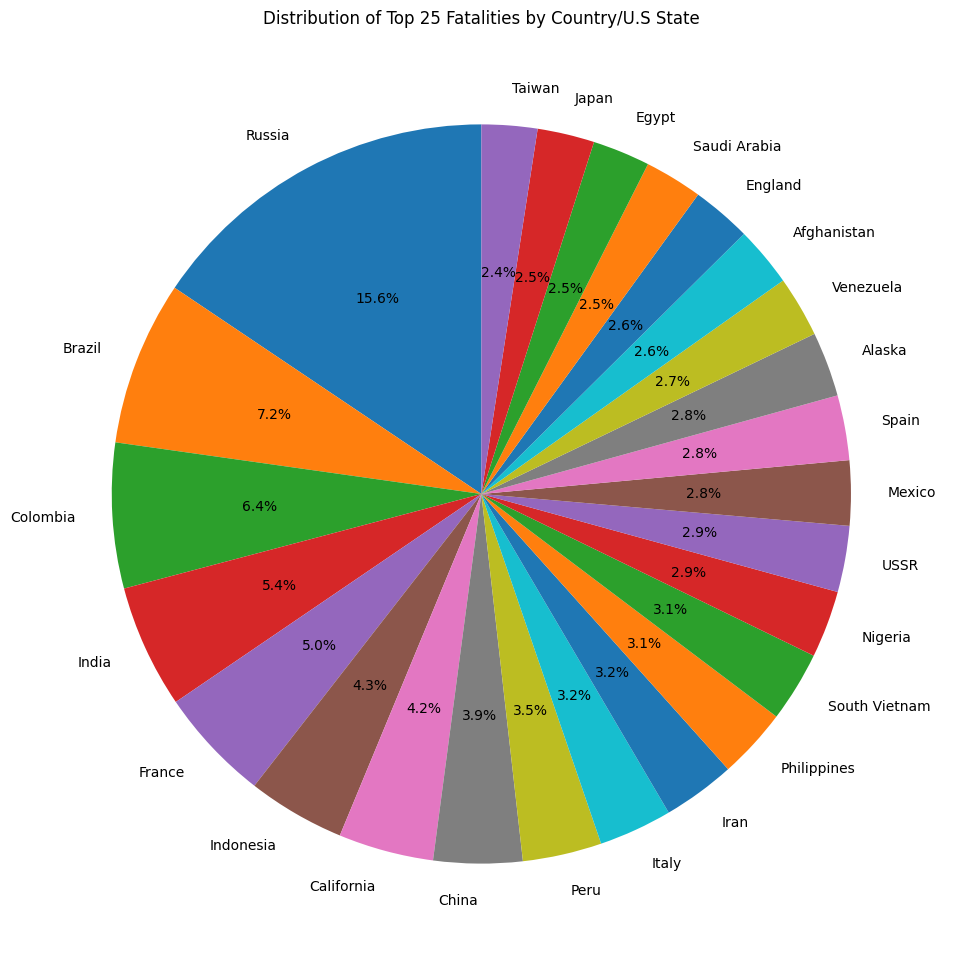

In [25]:
# Import the pyplot module from matpotlib and gives it the short name plt so that plottign functions can be called as plt, something instead of the full path
import matplotlib.pyplot as plt

# creates a new figure figsize(12,12) sets it to 12*12 inches whixh is big enough to fit 25 labelled slices clearly
plt.figure(figsize=(12,12))
plt.pie(
    top_25, #the actual numbers to plot, one per slice(fatality counts)
    labels=top_25.index, # the name shown next to each slice (country or state names)
    autopct='%1.1f%%', # displays each slice's share as a percentage with 1 decimal place
    startangle=90 # rotates the whole pie so the first slice starts at the top instead os the right side
)
# adds the title above the chart describing what it shows
plt.title('Distribution of Top 25 Fatalities by Country/U.S State')
#renders and displays the finished chart
plt.show()

![Team Photo](https://drive.google.com/uc?export=view&id=1P7abIJqWw242hjd62fTo839MpcocOzHx)